In [15]:
import xarray, numpy, math, scipy.interpolate
from argovisHelpers import helpers as avh

API_ROOT = 'https://argovis-api.colorado.edu/'
API_KEY = 'guest'

In [16]:
def datagrid(route, options, apikey='', apiroot='https://argovis-api.colorado.edu/', verbose=False):
    # perform a search exactly as query(...) on a grid or timeseries route,
    # and munge the results into an xarray.Dataset
    
    ## fetch raw data from Argovis
    griddata = avh.query(route, options=options, apikey=apikey, apiroot=apiroot, verbose=verbose)
    gridmeta = avh.query(route, options={**options, 'batchmeta':True}, apikey=apikey, apiroot=apiroot, verbose=verbose)
    metalookup = {x['_id']: x for x in gridmeta}

    ## is this a grid or a timeseries?
    isGrid = False
    isTS = False
    if 'levels' in gridmeta[0]:
        isGrid = True
    elif 'timeseries' in gridmeta[0]:
        isTS = True
    if not isGrid and not isTS:
        raise Exception('Use this function to search for gridded and timeseries data only.')

    ## needs to be very rectangular - in levels, longitudes, latitudes, timestamps and variables
    if isGrid:
        if 'verticalRange' in options or 'presRange' in options:
            ### level subset
            levels = [p['levels'] for p in griddata]
        else:
            ### full level spectrum
            levels = [m['levels'] for m in gridmeta]
        levels = list({x for sub in levels for x in sub})
        levels.sort()
    elif isTS:
        levels = [0] # assume this is just a surface grid
        tslvls = [d.get('level', None) for d in griddata] # try and see if there are level annotations
        tslvls = [x for x in tslvls if x is not None]
        if len(tslvls) > 0:
            levels = tslvls
            levels.sort()
    locations = [d['geolocation']['coordinates'] for d in griddata]
    longitudes = list(set([x[0] for x in locations]))
    longitudes.sort()
    latitudes = list(set([x[1] for x in locations]))
    latitudes.sort()
    if isGrid:
        timestamps = list(set([x['timestamp'] for x in griddata]))
        timestamps.sort()
    elif isTS:
        if 'startDate' in options or 'endDate' in options:
            ### time subset
            timestamps = [p['timeseries'] for p in griddata]
        else:
            ### full time spectrum
            timestamps = [m['timeseries'] for m in gridmeta]
        timestamps = list({x for sub in timestamps for x in sub})
        timestamps.sort()
    variables = [p['data_info'][0] for p in griddata]
    vars = list({x for sub in variables for x in sub})
    vars.sort()

    ## construct 4D data array
    darray = {}
    for v in vars:
        darray[v] = (('timestamp', 'longitude', 'latitude', 'level'), numpy.full((len(timestamps), len(longitudes), len(latitudes), len(levels)), numpy.nan, dtype=float))
    
    for p in griddata:
        m = metalookup[p['metadata'][0]]
        lvls = []
        if isGrid:
            if 'levels' in p:
                lvls = p['levels']
            else:
                lvls = m['levels']

        times = []
        if isTS:
            if 'timeseries' in p:
                times = p['timeseries']
            else:
                times = m['timeseries']
        
        lon_idx = longitudes.index(p['geolocation']['coordinates'][0])
        lat_idx = latitudes.index(p['geolocation']['coordinates'][1])
        if isGrid:
            time_idx = timestamps.index(p['timestamp'])
    
        for v in vars:
            if v in p['data_info'][0]:
                v_idx = p['data_info'][0].index(v)
                for i,val in enumerate(p['data'][v_idx]):
                    if isGrid:
                        lvl_idx = levels.index(lvls[i])
                    elif isTS:
                        time_idx = timestamps.index(times[i])
                        level = 0
                        if 'level' in p:
                            level = p['level']
                        lvl_idx = levels.index(level)
                    darray[v][1][time_idx][lon_idx][lat_idx][lvl_idx] = val

    return xarray.Dataset(darray,coords = {'timestamp':timestamps, 'longitude':longitudes, 'latitude':latitudes, 'level':levels})

def interpolate_to_levels(levels_raw, var_raw, levels_interp, pressure_buffer=-1, pressure_index_buffer=-1):
    # interpolate <var> to <levels> using PCHIP interpolation
    # keep <pressure_buffer> dbar on either side of the ROI and <pressure_index_buffer> points in the pressure buffer margins, at least.
    # flag 32 (little endian): ROI didn't contain enough info to interpolate

    flag = 0
    pressure, variable, flag = tidy_profile(levels_raw, var_raw, flag)

    # some truly pathological profiles will have no levels left at this point
    if len(pressure) == 0:
        interp = numpy.full(len(levels_interp), numpy.nan)
        flag = flag | 32
        return interp, flag

    # find indexes of ROI
    if pressure_buffer >= 0 and pressure_index_buffer >= 0:
        p_bracket = pad_bracket(pressure, levels_interp[0], levels_interp[-1], pressure_buffer, pressure_index_buffer)
    else:
        p_bracket = [0, len(pressure)-1]

    # ROI must contain at least two points for Pchip
    if len(pressure[p_bracket[0]:p_bracket[1]+1]) < 2:
        interp = numpy.full(len(levels_interp), numpy.nan)
        flag = flag | 32
        return interp, flag
    else:
        # interpolate; don't extrapolate to levels outside of measurement range
        interp = scipy.interpolate.PchipInterpolator(pressure[p_bracket[0]:p_bracket[1]+1], variable[p_bracket[0]:p_bracket[1]+1], extrapolate=False)(levels_interp)

        # if there wasn't a measured level within a certain radius of each level of interest, mask the interpolation at that level.
        interp = mask_far_interps(pressure[p_bracket[0]:p_bracket[1]+1], levels_interp, interp)

        return interp, flag

def tidy_profile(pressure, var, flag):
    # pchip needs pressures to be monotonically increasing; also need the dependent variable to always be defined
    # flags (little endian):
    # 1: degenerate adjacent levels
    # 2: levels in reverse order
    # 4: variable of interest was NaN, masked
    # 8: levels non-monotonic, had to sort
    # 16: pressure was NaN, masked

    ## dependent variable must be defined
    mask = [0]*len(var)
    for i in range(len(var)):
        if var[i] is None or math.isnan(var[i]):
            mask[i] = 1
            flag = flag | 4
    p = [pressure[i] for i in range(len(mask)) if mask[i]==0]
    v = [var[i] for i in range(len(mask)) if mask[i]==0]

    ## pressure must be defined
    mask = [0]*len(p)
    for i in range(len(p)):
        if p[i] is None or math.isnan(p[i]):
            mask[i] = 1
            flag = flag | 16
    p = [p[i] for i in range(len(mask)) if mask[i]==0]
    v = [v[i] for i in range(len(mask)) if mask[i]==0]

    ## drop degenerate levels and flag
    mask = [0]*len(p)
    for i in range(len(p)-1):
        if p[i] == p[i+1]:
            mask[i] = 1
            mask[i+1] = 1
            flag = flag | 1
    p = [p[i] for i in range(len(mask)) if mask[i]==0]
    v = [v[i] for i in range(len(mask)) if mask[i]==0]

    if all(p[i] < p[i + 1] for i in range(len(p) - 1)):
        # pressure is monotonically increasing, return
        return p, v, flag

    if all(p[i] > p[i + 1] for i in range(len(p) - 1)):
        # pressure is monotonically decreasing, reverse and return
        flag = flag | 2
        return p[::-1], v[::-1], flag

    # pressure is non-monotonic, sort and try again
    x = sorted(zip(p,v))
    p = [element[0] for element in x]
    v = [element[1] for element in x]
    flag = flag | 8
    return tidy_profile(p,v,flag)

def pad_bracket(lst, low_roi, high_roi, buffer, places):
    # returns the indexes of the last element below and first element above an ROI padded with <buffer>, and containing at least <places> elements in the padding.

    tight_bracket = find_bracket(lst, low_roi, high_roi)
    buffer_bracket = find_bracket(lst, low_roi - buffer, high_roi + buffer)

    low = buffer_bracket[0]
    if tight_bracket[0] - buffer_bracket[0] < places-1: # -1 since find_bracket gives the first bound in the wing, so there's already one point in the wing even for tight_bracket
        low = max(0, tight_bracket[0] - places+1)

    high = buffer_bracket[1]
    if buffer_bracket[1] - tight_bracket[1] < places-1:
        high = min(len(lst)-1, tight_bracket[1] + places-1)

    return low, high

def mask_far_interps(measured_pressures, interp_levels, interp_values):
    # mask interpolated values that are too far from the nearest measured level

    for i, level in enumerate(interp_levels):
        ## determine how far is too far:
        radius = 0
        if level < 100:
            radius = 10
        elif level < 150:
            radius = 20
        elif level < 250:
            radius = 40
        elif level < 350:
            radius = 60
        elif level < 450:
            radius = 80
        else:
            radius = 100

        i_below = 0
        i_above = len(measured_pressures)-1
        for j in range(len(measured_pressures)):
            if measured_pressures[j] <= level:
                i_below = j
            else:
                i_above = j
                break
        if abs(measured_pressures[i_below] - level) > radius or abs(measured_pressures[i_above] - level) > radius:
            interp_values[i] = numpy.nan

    return interp_values

def find_bracket(lst, low_roi, high_roi):
    # lst: ordered list of floats
    # low_roi: lower bound of region of interest
    # high_roi: upper bound "
    # returns the indexes of the last element below and first element above the ROI, without running off ends of list

    if low_roi <= lst[0]:
        low_index = 0
    else:
        low = 0
        high = len(lst) - 1
        low_index = -1

        while low <= high:
            mid = (low + high) // 2

            if lst[mid] < low_roi:
                low_index = mid
                low = mid + 1
            else:
                high = mid - 1

    if high_roi >= lst[-1]:
        high_index = len(lst) - 1
    else:
        low = 0
        high = len(lst) - 1
        high_index = -1

        while low <= high:
            mid = (low + high) // 2

            if lst[mid] > high_roi:
                high_index = mid
                high = mid - 1
            else:
                low = mid + 1

    return low_index, high_index

def interpolate_all(profile, levels, pressure_buffer=-1, pressure_index_buffer=-1):
    # remove any QC vectors
    variables = profile['data_info'][0]
    qcvecs = ['qc' in x for x in variables] # a bit duck-typie...
    data = [x for i,x in enumerate(profile['data']) if not qcvecs[i]]
    data_info = [None, None, None]
    data_info[0] = [x for i,x in enumerate(profile['data_info'][0]) if not qcvecs[i]]
    data_info[1] = profile['data_info'][1]
    data_info[2] = [x for i,x in enumerate(profile['data_info'][2]) if not qcvecs[i]]

    level_idx = data_info[0].index('pressure')
    raw_levels = data[level_idx]

    for i in range(len(data_info[0])):
        if i == level_idx:
            data[i] = levels
        else:
            data[i], _ = interpolate_to_levels(raw_levels, data[i], levels, pressure_buffer, pressure_index_buffer)
            data[i] = list(data[i])

    return {**profile, 'data':data, 'data_info':data_info}


def query_interpolated(route, options, apikey='', apiroot='https://argovis-api.colorado.edu/', levels=None, format_dataset=False, verbose=False, pressure_buffer=-1, pressure_index_buffer=-1):

    ## request validation
    if 'data' not in options:
        raise Exception('Interpolated queries require some level data to interpolate on; please add a data request to your query options.')
        return
    if levels is None:
        print("warning: you didn't provide a level spectrum to interpolate on; using the Roemmich-Gilson levels by default.")
        levels = [2.5,10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,182.5,200,220,240,260,280,300,320,340,360,380,400,420,440,462.5,500,550,600,650,700,750,800,850,900,950,1000,1050,1100,1150,1200,1250,1300,1350,1412.5,1500,1600,1700,1800,1900,1975]

    ## fetch raw data from Argovis
    rawdata = avh.query(route, options=options, apikey=apikey, apiroot=apiroot, verbose=verbose)

    interpolated_profiles = [interpolate_all(x, levels, pressure_buffer, pressure_index_buffer) for x in rawdata]
    
    if not format_dataset:
        return interpolated_profiles

    # munge into an xarray dataset dimensioned by a profile index and levels, in analogy to Argo GDAC files
    nprofs = range(len(interpolated_profiles))
    variables = [p['data_info'][0] for p in interpolated_profiles]
    vars = list({x for sub in variables for x in sub})
    vars.sort()

    darray = {}
    for v in vars:
        darray[v] = (('nprof', 'level'), numpy.full((len(nprofs), len(levels)), numpy.nan, dtype=float))

    for i, p in enumerate(interpolated_profiles):
        prof_idx = i
        for v in vars:
            if v in p['data_info'][0]:
                v_idx = p['data_info'][0].index(v)
                for j,val in enumerate(p['data'][v_idx]):
                    lvl_idx = j
                    darray[v][1][prof_idx][lvl_idx] = val

    # form coordinates (ie metadata)
    ids = [p['_id'] for p in interpolated_profiles]
    longitudes = [p['geolocation']['coordinates'][0] for p in interpolated_profiles]
    latitudes = [p['geolocation']['coordinates'][1] for p in interpolated_profiles]
    timestamps = [p['timestamp'] for p in interpolated_profiles]
    
    coords = {
        "id": ("nprof", ids),
        "longitude": ("nprof", longitudes),
        "latitude": ("nprof", latitudes),
        "timestamp": ("nprof", timestamps)
    }

    attrs = {}
    return xarray.Dataset(darray,coords,attrs)

# 1. Interpolations

Let's begin by downloading some Argo data as usual, and interpolating it to some standard levels with `interpolate_to_levels`. This interpolation scheme uses Scipy's pchip interpolator, with some opinionated filters:

 - Levels will only be interpolated to if they are inside the range of levels actually measured in the profile.
 - Interpolated levels will be masked as nan if the original profile doesn't have a measured levels above and below the target level and sufficiently close to it. See `mask_for_interps` for the definition of 'sufficiently close'.
 - Interpolation will use the entire profile by default; see `pressure_buffer` and `pressure_index_buffer` args to interpolate over limited regions.

In [17]:
argo_qsp = {
    "polygon": [[-52.382812,53.225768],[-62.050781,48.107431],[-72.773438,43.325178],[-77.695313,37.996163],[-81.5625,32.990236],[-82.089844,27.683528],[-78.925781,22.755921],[-71.547389,23.008026],[-64.160156,22.917923],[-57.673458,28.712256],[-50.449219,34.161818],[-40.078125,44.590467],[-35.683594,51.618017],[-43.066406,54.265224],[-52.382812,53.225768]],
    "startDate": '2025-01-01T00:00:00Z',
    "endDate": '2025-02-01T00:00:00Z',
    "data": 'all'
}

argodata = avh.query('argo', argo_qsp, API_KEY, API_ROOT)

In [18]:
# choose an arbitrary profile, pick out pressure and a variable of interest, and use the helper to interpolate to a level spectrum.

pidx = 0
level_spectrum = [100,200,300,400,500]
p_idx = argodata[pidx]['data_info'][0].index('pressure')
t_idx = argodata[pidx]['data_info'][0].index('temperature')
raw_pressure = argodata[pidx]['data'][p_idx]
raw_temp = argodata[pidx]['data'][t_idx]

interp_temp, _ = interpolate_to_levels(raw_pressure, raw_temp, level_spectrum)
print(interp_temp)

[16.054001   16.079      14.01518112 11.69631205  9.59968628]


In [19]:
interpolate_all(argodata[pidx], [100,200,300,400,500])

{'_id': '3902458_078',
 'geolocation': {'type': 'Point',
  'coordinates': [-40.821331666666666, 44.45778]},
 'basin': 1,
 'timestamp': '2025-01-31T23:36:30.000Z',
 'date_updated_argovis': '2025-02-01T08:29:57.713Z',
 'source': [{'source': ['argo_core'],
   'url': 'ftp://ftp.ifremer.fr/ifremer/argo/dac/coriolis/3902458/profiles/R3902458_078.nc',
   'date_updated': '2025-02-01T00:32:02.000Z'}],
 'cycle_number': 78,
 'geolocation_argoqc': 1,
 'profile_direction': 'A',
 'timestamp_argoqc': 1,
 'vertical_sampling_scheme': 'Primary sampling: averaged [10 sec sampling, 5 dbar average from 2000 dbar to 1400 dbar; 10 sec sampling, 2 dbar average from 1400 dbar to 400 dbar; 10 sec sampling, 1 dbar average from 400 dbar to 5.0 dbar]',
 'data': [[100, 200, 300, 400, 500],
  [36.06864935746527,
   36.070999,
   35.77627802330296,
   35.44403217628436,
   35.193552952544565],
  [16.054001,
   16.079,
   14.015181118497262,
   11.69631204679539,
   9.599686279484946]],
 'data_info': [['pressure', 'sa

In [20]:
qsp = {
    'platform': 4903575,
    'data': 'temperature,1,salinity,1'
}

interpolated_data = query_interpolated('/argo', qsp)

In [21]:
interpolated_data

[{'_id': '4903575_069',
  'geolocation': {'type': 'Point', 'coordinates': [-169.282, 29.597]},
  'basin': 2,
  'timestamp': '2025-09-18T16:03:11.001Z',
  'date_updated_argovis': '2025-09-19T07:00:10.784Z',
  'source': [{'source': ['argo_core'],
    'url': 'ftp://ftp.ifremer.fr/ifremer/argo/dac/aoml/4903575/profiles/R4903575_069.nc',
    'date_updated': '2025-09-18T19:01:34.000Z'}],
  'cycle_number': 69,
  'geolocation_argoqc': 1,
  'profile_direction': 'A',
  'timestamp_argoqc': 1,
  'vertical_sampling_scheme': 'Primary sampling: mixed [deep: discrete, shallow: averaged]',
  'data': [[nan,
    27.997,
    27.984332415557372,
    27.65813995576474,
    23.63748168264714,
    21.955589142108433,
    20.640673075990154,
    19.67625713161216,
    19.209441413443393,
    18.155107888602362,
    17.565969700226578,
    17.14087893207039,
    16.7655641055477,
    16.457114362872222,
    16.16062558220101,
    15.942055260258961,
    15.756480223945061,
    15.439013323429043,
    15.1543627

In [22]:
interpolated_data = query_interpolated('/argo', qsp, format_dataset=True)
interpolated_data

<xarray.Dataset>
Dimensions:      (nprof: 68, level: 58)
Coordinates:
    id           (nprof) <U11 '4903575_069' '4903575_068' ... '4903575_002'
    longitude    (nprof) float64 -169.3 -169.4 -169.6 ... -166.9 -166.8 -166.8
    latitude     (nprof) float64 29.6 29.48 29.43 29.4 ... 28.74 28.73 28.81
    timestamp    (nprof) <U24 '2025-09-18T16:03:11.001Z' ... '2023-11-01T13:2...
Dimensions without coordinates: nprof, level
Data variables:
    pressure     (nprof, level) float64 2.5 10.0 20.0 ... 1.9e+03 1.975e+03
    salinity     (nprof, level) float64 nan 35.32 35.32 ... 34.59 34.6 34.61
    temperature  (nprof, level) float64 nan 28.0 27.98 27.66 ... 2.13 2.02 1.95

# 2. Grids & timeseries in xarray

Use the `datagrid` helper to download gridded or timeseries data and automatically load it into an xarray dataset dimensioned by longitude, latitude, time and level. Pass routes and query string parameters just as you would a normal `query`:

In [23]:
griddata_qsp = {
    "polygon": [[-52.382812,53.225768],[-62.050781,48.107431],[-72.773438,43.325178],[-77.695313,37.996163],[-81.5625,32.990236],[-82.089844,27.683528],[-78.925781,22.755921],[-71.547389,23.008026],[-64.160156,22.917923],[-57.673458,28.712256],[-50.449219,34.161818],[-40.078125,44.590467],[-35.683594,51.618017],[-43.066406,54.265224],[-52.382812,53.225768]],
    "startDate": '2024-01-01T00:00:00Z',
    "endDate": '2025-01-01T00:00:00Z',
    "verticalRange": [0,1000],
    "data": 'all'
}

xar = datagrid('grids/rg09', griddata_qsp, API_KEY, API_ROOT)

In [24]:
xar

<xarray.Dataset>
Dimensions:           (timestamp: 12, longitude: 44, latitude: 31, level: 43)
Coordinates:
  * timestamp         (timestamp) <U24 '2024-01-15T00:00:00.000Z' ... '2024-1...
  * longitude         (longitude) float64 -79.5 -78.5 -77.5 ... -37.5 -36.5
  * latitude          (latitude) float64 23.5 24.5 25.5 26.5 ... 51.5 52.5 53.5
  * level             (level) float64 2.5 10.0 20.0 30.0 ... 850.0 900.0 950.0
Data variables:
    rg09_salinity     (timestamp, longitude, latitude, level) float64 nan ......
    rg09_temperature  (timestamp, longitude, latitude, level) float64 nan ......

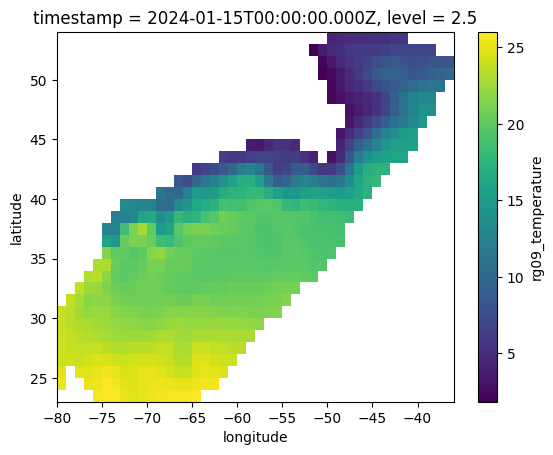

In [25]:
xar["rg09_temperature"].isel(timestamp=0, level=0).plot(x='longitude', y='latitude') 

In [26]:
tsdata_qsp = {
    "polygon": [[-40,-40],[-40,-30],[-30,-30],[-30,-40],[-40,-40]],
    "startDate": "1993-01-09T00:00:00Z",
    "endDate": "1993-01-11T00:00:00Z",
    "data": 'all'
}

ts_xar = datagrid('timeseries/ccmpwind', tsdata_qsp, API_KEY, API_ROOT, verbose=True)

https://argovis-api.colorado.edu/timeseries/ccmpwind?polygon=[[-40,+-40],+[-40,+-30],+[-30,+-30],+[-30,+-40],+[-40,+-40]]&startDate=1993-01-09T00:00:00Z&endDate=1993-01-11T00:00:00Z&data=all
https://argovis-api.colorado.edu/timeseries/ccmpwind?polygon=[[-40,+-40],+[-40,+-30],+[-30,+-30],+[-30,+-40],+[-40,+-40]]&startDate=1993-01-09T00:00:00Z&endDate=1993-01-11T00:00:00Z&data=all&batchmeta=True


In [27]:
ts_xar

<xarray.Dataset>
Dimensions:    (timestamp: 1, longitude: 40, latitude: 40, level: 1)
Coordinates:
  * timestamp  (timestamp) <U24 '1993-01-10T00:00:00.000Z'
  * longitude  (longitude) float64 -39.88 -39.62 -39.38 ... -30.62 -30.38 -30.12
  * latitude   (latitude) float64 -39.88 -39.62 -39.38 ... -30.62 -30.38 -30.12
  * level      (level) int64 0
Data variables:
    nobs       (timestamp, longitude, latitude, level) float64 14.0 ... 12.0
    uwnd       (timestamp, longitude, latitude, level) float64 6.644 ... 2.717
    vwnd       (timestamp, longitude, latitude, level) float64 -0.8013 ... -3...
    ws         (timestamp, longitude, latitude, level) float64 8.592 ... 6.431

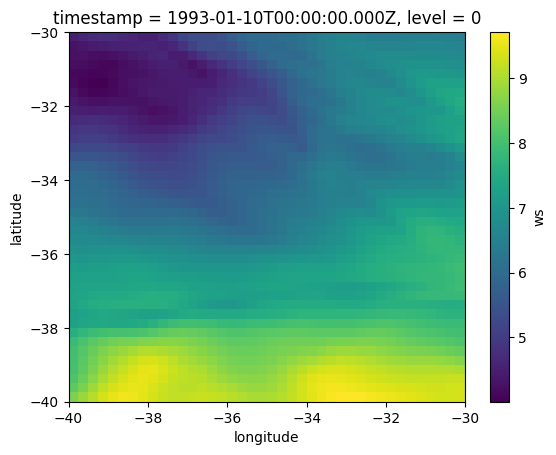

In [28]:
ts_xar["ws"].isel(timestamp=0, level=0).plot(x='longitude', y='latitude') 